# Individuality dimensions with LDA

In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# --Machine learning and statistics

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import umap
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from statsmodels.distributions.empirical_distribution import ECDF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats
from sklearn.metrics import f1_score
from scipy.stats import zscore

# Get my functions
from functions import get_metadata
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette

from one.api import ONE
one = ONE(mode='remote')

In [3]:
""" IMPORTANT PATHS """
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'

## Load sequence data

In [139]:
filename = base_path + '10_bin_syllables_17-06-2026'
# filename = base_path + '10_bin_raw_16-06-2026'
# filename = base_path + 'all_trials_16-06-2026'
# filename = base_path + 'all_sequences_26-03-2026'
all_sequences = pd.read_parquet(filename)

if 'syllables' in filename or 'sequences' in filename or 'raw' in filename:     
    all_sequences['session'] = all_sequences['sample'].str[:36]  

### Filter data

In [140]:
print(str(len(all_sequences.mouse_name.unique())) + str(' mice in total'))
print(str(len(all_sequences.session.unique())) + str(' sessions in total'))

# Filter out bad sessions
prob_sessions = [
'30af8629-7b96-45b7-8778-374720ddbc5e',
'90e524a2-aa63-47ce-b5b8-1b1941a1223a',
'a8a8af78-16de-4841-ab07-fde4b5281a03',
'49368f16-de69-4647-9a7a-761e94517821',
'a71175be-d1fd-47a3-aa93-b830ea3634a1',
'0deb75fb-9088-42d9-b744-012fb8fc4afb',
'02fbb6da-3034-47d6-a61b-7d06c796a830',
'7f6b86f9-879a-4ea2-8531-294a221af5d0',
'8c33abef-3d3e-4d42-9f27-445e9def08f9',
'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
'510b1a50-825d-44ce-86f6-9678f5396e02']

# FIX: Use drop=True to avoid creating 'index' column
all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
print(str(len(all_sequences['session'].unique())) + str(' sessions after removing bad sessions'))

# Filter out mice without enough sessions
session_count = all_sequences[['mouse_name', 'session']].drop_duplicates().groupby(['mouse_name'])['session'].count().reset_index()
multi_sess_mice = session_count.loc[session_count['session']>2, 'mouse_name']

# FIX: Use drop=True here too
all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
print(str(len(multi_sess_mice)) + str(' mice with at least 3 sessions'))
print(str(len(all_sequences['session'].unique())) + str(' remaining sessions'))

# Validation
assert 'index' not in all_sequences.columns, "ERROR: 'index' column created by reset_index!"
print("✓ Data preparation validated")

102 mice in total
318 sessions in total
307 sessions after removing bad sessions
56 mice with at least 3 sessions
248 remaining sessions
✓ Data preparation validated


# Encode syllables for LDA

In [141]:
def binarize(n_features_per_step, use_sequences):

    n_trials = use_sequences.shape[0]
    timesteps = use_sequences.shape[1]

    binarized = np.zeros((n_trials, timesteps * n_features_per_step))
    for t in range(timesteps):
        # current_step_codes 
        current_vals = use_sequences[:, t]
        # Identify NaN values
        nan_mask = np.isnan(current_vals)
        # Only process non-NaN values
        valid_mask = ~nan_mask
        labels_0idx = current_vals[valid_mask].astype(int)
        start_col = t * n_features_per_step
        
        if len(labels_0idx) > 0:  # Only if there are valid values
            # 1. Fill Paw States (Cols 0-7) for valid trials only
            paw_indices = labels_0idx % 8
            valid_row_idx = np.arange(n_trials)[valid_mask]
            binarized[valid_row_idx, start_col + paw_indices] = 1
            # 2. Fill Whisking (Col 8) for valid trials only
            binarized[valid_mask, start_col + 8] = ((labels_0idx // 8) % 2).astype(int)
            # 3. Fill Licking (Col 9) for valid trials only
            binarized[valid_mask, start_col + 9] = (labels_0idx // 16).astype(int)
        
        # Set all features for this timestep to NaN where original data was NaN
        if np.any(nan_mask):
            feature_cols = slice(start_col, start_col + n_features_per_step)
            binarized[nan_mask, feature_cols] = np.nan

    # Delete Paw State 8 (index 7) for every timestep to avoid collinearity
    cols_to_delete = [t * 10 + 7 for t in range(timesteps)]
    binarized_9d = np.delete(binarized, cols_to_delete, axis=1)

    # If Paw State 2 is at index 1 (0-indexed)
    cols_to_delete = [t * 10 + 1 for t in range(timesteps)]
    binarized_9d_ref2 = np.delete(binarized, cols_to_delete, axis=1)
    
    return binarized_9d, binarized_9d_ref2

In [142]:
if 'syllables' in filename or 'sequences' in filename:     
    # all_sequences['session'] = all_sequences['sample'].str[:36]  
    design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
    # Remove any spurious 'index' column created by reset_index
    if 'index' in design_df.columns:
        design_df = design_df.drop(columns=['index'])
    design_df = design_df.sort_values(by='session')
    
    # Validate
    assert len(design_df) > 0, "ERROR: design_df is empty after filtering!"
    print(f"✓ design_df created: {len(design_df)} rows, {design_df['mouse_name'].nunique()} mice, {design_df['session'].nunique()} sessions")
    
    epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
    use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
    
    # Validate alignment
    assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length ({len(use_sequences)}) != design_df length ({len(design_df)})"
    
    # --- PARAMETERS ---
    n_paw_states = 8
    n_features_per_step = 10  # 8 Paw + 1 Whisk + 1 Lick
    binarized_9d, binarized_9d_ref2 = binarize(n_features_per_step, use_sequences)
    use_format = binarized_9d_ref2.copy()
    
elif 'raw' in filename:
    all_sequences['session'] = all_sequences['sample'].str[:36]
    binned_vars = ['Lick count_binned_sequence', 'whisker_me_binned_sequence', 
                   'l_paw_x_vel_binned_sequence', 'l_paw_y_vel_binned_sequence', 
                   'r_paw_x_vel_binned_sequence', 'r_paw_y_vel_binned_sequence']
    design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values=binned_vars).reset_index().dropna()
    if 'index' in design_df.columns:
        design_df = design_df.drop(columns=['index'])
    design_df = design_df.sort_values(by='session')
    # var_names = design_df.keys()[-4:]
    epoch_to_analyse = design_df.keys()[4:]
    use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
    
    assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length != design_df length"
    
    # Normalize
    use_format = zscore(use_sequences, axis=0, nan_policy='omit')

elif 'trial' in filename:
    design_df = all_sequences.dropna()
    design_df['choice'] = design_df['choice'].map({'left': 0, 'right': 1}).astype(float)
    bias_df = (design_df[design_df['contrast'] == 0]
            .groupby(['session', 'block'])['choice'].mean()
            .unstack(level='block'))
    bias_df['bias'] = bias_df[0.8] - bias_df[0.2]
    merged = (design_df.groupby(['session', 'mouse_name'])
            .agg({'reaction': 'median', 'elongation': 'median', 'correct': 'mean', 'choice': 'mean'})
            .merge(bias_df['bias'], on='session', how='left'))

    merged['log_reaction'], merged['log_elongation'] = np.log(merged['reaction']), np.log(merged['elongation'])
    features = ['correct', 'choice', 'log_reaction', 'log_elongation', 'bias']
    # use_format = merged[features].to_numpy()
    # use_format = zscore(use_format, axis=0, nan_policy='omit')
    clean_df = merged[features].dropna()
    use_format = clean_df.to_numpy()
    use_format = zscore(use_format, axis=0)
    
    design_df = clean_df.reset_index().merge(design_df[['mouse_name', 'session']], on='session').drop_duplicates()

✓ design_df created: 154367 rows, 56 mice, 248 sessions


## Average per session

In [143]:
# Create session-to-mouse mapping BEFORE aggregation (critical fix!)
session_mouse_mapping = design_df[['session', 'mouse_name']].drop_duplicates()
session_mouse_mapping = session_mouse_mapping.set_index('session')['mouse_name'].to_dict()

# Validate: each session maps to exactly one mouse
assert len(session_mouse_mapping) == len(design_df[['session', 'mouse_name']].drop_duplicates()),     "ERROR: A session maps to multiple mice!"

# Now aggregate data
session_syllables = pd.DataFrame(use_format)
session_syllables['session'] = design_df['session'].values
session_syllables = session_syllables.groupby('session', sort=False)[np.arange(0, np.shape(use_format)[1], 1)].mean()

# Create mouse name labels using explicit mapping
mouse_names_list = np.array([session_mouse_mapping[sess] for sess in session_syllables.index])

print(f"✓ Session aggregation complete: {len(session_syllables)} sessions")
print(f"✓ Mouse labels: {dict(zip(*np.unique(mouse_names_list, return_counts=True)))}")


✓ Session aggregation complete: 248 sessions
✓ Mouse labels: {np.str_('CSHL045'): np.int64(5), np.str_('CSHL049'): np.int64(4), np.str_('CSHL052'): np.int64(4), np.str_('CSHL053'): np.int64(3), np.str_('CSHL058'): np.int64(3), np.str_('CSHL059'): np.int64(5), np.str_('CSHL060'): np.int64(5), np.str_('CSH_ZAD_019'): np.int64(3), np.str_('CSH_ZAD_026'): np.int64(6), np.str_('CSH_ZAD_029'): np.int64(4), np.str_('DY_009'): np.int64(9), np.str_('DY_010'): np.int64(4), np.str_('DY_011'): np.int64(4), np.str_('DY_014'): np.int64(6), np.str_('DY_016'): np.int64(5), np.str_('DY_018'): np.int64(3), np.str_('DY_020'): np.int64(8), np.str_('NR_0019'): np.int64(3), np.str_('NR_0020'): np.int64(4), np.str_('NR_0021'): np.int64(3), np.str_('NR_0027'): np.int64(4), np.str_('NYU-30'): np.int64(3), np.str_('NYU-39'): np.int64(5), np.str_('NYU-40'): np.int64(4), np.str_('NYU-45'): np.int64(3), np.str_('NYU-46'): np.int64(4), np.str_('NYU-47'): np.int64(3), np.str_('NYU-48'): np.int64(3), np.str_('NYU-65'

Text(0, 0.5, 'Sessions')

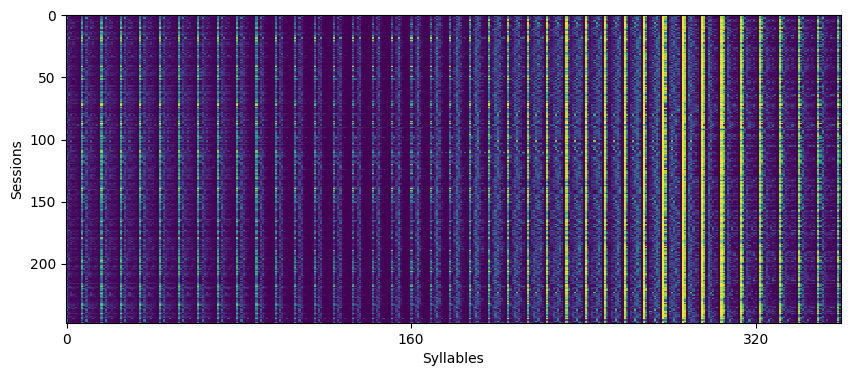

In [144]:
plt.figure(figsize=(10, 4))
plt.imshow(np.array(session_syllables), aspect='auto', cmap='viridis', interpolation='none')
plt.xticks(np.arange(0, np.shape(use_format)[1], 160), np.arange(0, np.shape(use_format)[1], 160))
plt.xlabel('Syllables')
plt.ylabel('Sessions')

# Dimensionality reduction

In [145]:
all_features = session_syllables.copy()

23 components explain 0.95 of total variance


Text(0.5, 1.0, 'Explained Variance by PCA')

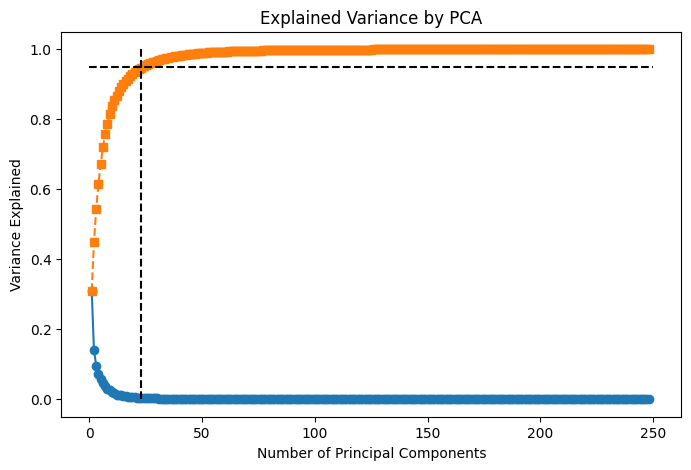

In [146]:
# PCA
n_components = np.min([np.shape(np.array(all_features))[0], np.shape(np.array(all_features))[1]])
# Step 1: Reduce dimensions with PCA
pca = PCA(n_components)  # Reduce to 50 dimensions
scaler = StandardScaler()
# standardized_X = scaler.fit_transform(np.array(all_features))
# X_pca = pca.fit_transform(standardized_X)
X_pca = pca.fit_transform(np.array(all_features))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
threshold = 0.95
min_components = np.where(cumulative_variance>0.95)[0][0]
# min_components = 28
print(str(min_components) + ' components explain ' + str(threshold) +' of total variance')

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
plt.hlines(threshold, 0, 250, 'black', 'dashed')
plt.vlines(min_components, 0, 1, 'black', 'dashed')
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA")

In [147]:
mat = np.array(session_syllables.copy())
mat = np.array(X_pca[:, :min_components])

scaler = StandardScaler()
norm_pop = scaler.fit_transform(mat.copy())

# LDA

In [ ]:
mapping = pd.DataFrame(np.array(design_df[['mouse_name', 'session']].drop_duplicates()), columns=['mouse_name', 'session'])
df_with_sessions = session_syllables.reset_index()
mouse_names = df_with_sessions.merge(mapping, on=['session'])['mouse_name']
df = df_with_sessions.merge(mapping, on=['session'])

In [150]:
mouse_names = df_with_sessions.merge(mapping, on=['session'])['mouse_name']
df = df_with_sessions.merge(mapping, on=['session'])

In [151]:
1/len(mouse_names.unique())

0.017857142857142856

In [152]:
n_per_mouse = 3
lda_components = 30
lda_components = np.min([min_components, len(mouse_names.unique())-1])
# lda_components = 30
n_repeats = 10

final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Store repeat results
true_scores_all = []
shuffle_scores_all = []

for repeat in range(n_repeats):
    scores_true = []
    scores_shuff = []

    # Subsample balanced sessions for training in each fold
    for test_idx in range(n_samples):
        X_test = X[test_idx:test_idx+1]
        y_test = y[test_idx:test_idx+1]
        train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
        X_train_full = X[train_idx]
        y_train_full = y[train_idx]

        # --- balanced subsampling for training ---
        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            if len(m_idx) >= n_per_mouse-1:
                balanced_idx.extend(rng.choice(m_idx, n_per_mouse-1, replace=False))
            # else:
                # print(m)
        balanced_idx = np.array(balanced_idx)
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        # --- true labels run ---
        lda = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
            n_components=lda_components)
        lda.fit(X_train, y_train)
        scores_true.append(lda.score(X_test, y_test))

        # --- shuffled labels run ---
        y_train_shuff = y_train.copy()
        rng.shuffle(y_train_shuff)
        lda_shuff = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train_shuff))) / len(np.unique(y_train_shuff)),
            n_components=lda_components)
        lda_shuff.fit(X_train, y_train_shuff)
        scores_shuff.append(lda_shuff.score(X_test, y_test))
        
    # store average score for this repeat
    true_scores_all.append(np.mean(scores_true))
    shuffle_scores_all.append(np.mean(scores_shuff))

print("True labels mean ± std:", np.mean(true_scores_all), np.std(true_scores_all))
print("Shuffled labels mean ± std:", np.mean(shuffle_scores_all), np.std(shuffle_scores_all))

True labels mean ± std: 0.7564516129032258 0.02041772403414863
Shuffled labels mean ± std: 0.016935483870967737 0.008419602023314961


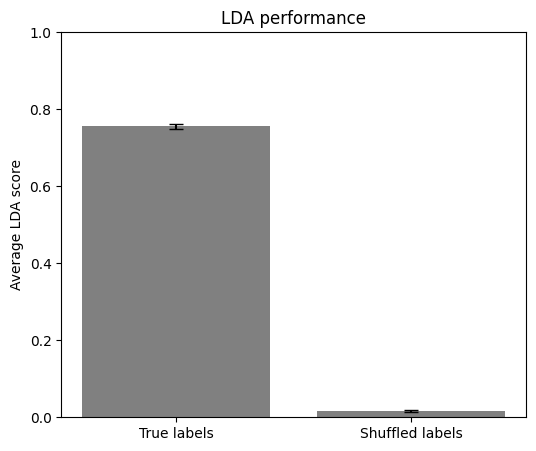

In [153]:
# Convert to arrays for convenience
true_scores = np.array(true_scores_all)
shuffle_scores = np.array(shuffle_scores_all)

# Compute means and standard deviations
means = [np.mean(true_scores), np.mean(shuffle_scores)]
stds  = [np.std(true_scores), np.std(shuffle_scores)]
std_errs = [np.std(true_scores)/np.sqrt(len(true_scores)), 
            np.std(shuffle_scores)/np.sqrt(len(shuffle_scores))]

labels = ['True labels', 'Shuffled labels']

# Create bar plot with error bars
plt.figure(figsize=(6,5))
plt.bar(labels, means, yerr=std_errs, color='grey', capsize=5) #, color=['skyblue','lightcoral']
plt.ylabel('Average LDA score')
plt.title('LDA performance')
plt.ylim(0,1)
# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'lda_score.svg', format='svg', bbox_inches='tight')
plt.show()